In [13]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- STEP 1: LOAD & SUMMARIZE (MEMORY-SAFE) ---
input_path = 'C:\\my-dublin-bikes-project\\outputs\\bikes_cleaned.csv'
chunk_size = 500000
partial_results = []

print("Aggregating 36 million rows... this will take a minute.")

for chunk in pd.read_csv(input_path, chunksize=chunk_size):
    # Group by station within each chunk
    summary = chunk.groupby('STATION ID').agg({
        'occupancy_rate': 'sum',   
        'BIKE_STANDS': 'mean',
        'LATITUDE': 'first',
        'LONGITUDE': 'first',
        'ADDRESS': 'first'
    })
    summary['row_count'] = chunk.groupby('STATION ID').size()
    partial_results.append(summary)

# Combine chunks into a single row per station
station_usage = pd.concat(partial_results).groupby('STATION ID').agg({
    'occupancy_rate': 'sum',
    'row_count': 'sum',
    'BIKE_STANDS': 'mean',
    'LATITUDE': 'first',
    'LONGITUDE': 'first',
    'ADDRESS': 'first'
}).reset_index()

# Calculate true average occupancy (Total Sum / Total Count)
station_usage['occupancy_rate'] = station_usage['occupancy_rate'] / station_usage['row_count']
station_usage = station_usage.drop(columns=['row_count'])

Aggregating 36 million rows... this will take a minute.


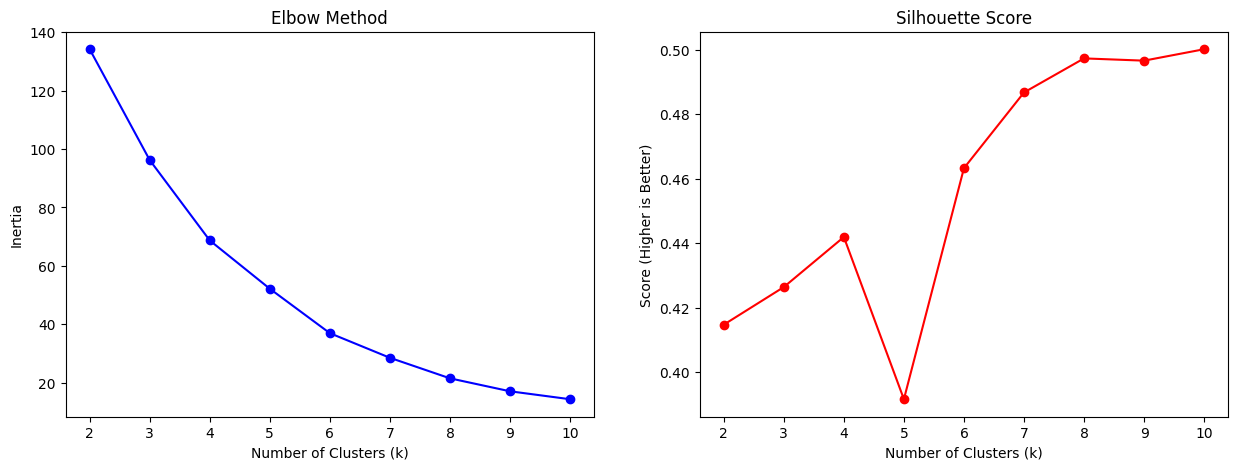

In [14]:
# --- STEP 2: ELBOW & SILHOUETTE ANALYSIS ---
# Prepare features for clustering
X = StandardScaler().fit_transform(station_usage[['occupancy_rate', 'BIKE_STANDS']])

inertia = []
sil_scores = []
K = range(2, 11) # Silhouette requires at least 2 clusters

for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Plotting both side-by-side to show complexity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
ax1.plot(range(2, 11), inertia, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

# Silhouette Plot
ax2.plot(range(2, 11), sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Score (Higher is Better)')
plt.show()

In [15]:
# --- STEP 3: FINAL CLUSTERING ---
# Use the best k (usually 3 or 4 for this data)
optimal_k = 4 
station_usage['cluster'] = KMeans(n_clusters=optimal_k, n_init=10, random_state=42).fit_predict(X)
print(f"Average Silhouette Score for k={optimal_k}: {silhouette_score(X, station_usage['cluster']):.3f}")

Average Silhouette Score for k=4: 0.442


In [16]:
# --- STEP 4: INTERACTIVE MAPPING ---
# Create the base map of Dublin
m = folium.Map(location=[53.3498, -6.2603], zoom_start=13)
colors = ['blue', 'green', 'orange', 'red']

for _, row in station_usage.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=8, color=colors[int(row['cluster'])], fill=True, fill_opacity=0.7,
        popup=f"<b>{row['ADDRESS']}</b><br>Usage: {row['occupancy_rate']:.1%}"
    ).add_to(m)

In [17]:
# --- STEP 5: ADD THE SCALE (LEGEND) ---
legend_html = f"""
     <div style="
     position: fixed; 
     top: 20px; right: 20px; width: 180px; height: 130px; 
     background-color: white; border:2px solid grey; z-index:10000; font-size:13px;
     padding: 10px; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.5);
     pointer-events: none;
     ">
     <b>Station Usage Key</b><br>
     <i class="fa fa-circle" style="color:blue"></i> Cluster 0: Very Low<br>
     <i class="fa fa-circle" style="color:green"></i> Cluster 1: Low<br>
     <i class="fa fa-circle" style="color:orange"></i> Cluster 2: Medium<br>
     <i class="fa fa-circle" style="color:red"></i> Cluster 3: High
     </div>
     """

# Inject the legend into the map
m.get_root().html.add_child(folium.Element(legend_html))

In [18]:
# --- STEP 6: SAVE ---
m.save('dublin_usage_map.html')
print("✅ Map updated with Top-Right legend! Re-open 'dublin_usage_map.html' in your browser.")

✅ Map updated with Top-Right legend! Re-open 'dublin_usage_map.html' in your browser.
